# Mini Project 5-2 Explore Probability Distributions

## **Introduction**

The ability to determine which type of probability distribution best fits data, calculate z-score, and detect outliers are essential skills in data work. These capabilities enable data professionals to understand how their data is distributed and identify data points that need further examination.

In this activity, you are a member of an analytics team for the United States Environmental Protection Agency (EPA). The data includes information about more than 200 sites, identified by state, county, city, and local site names. One of your main goals is to determine which regions need support to make air quality improvements. Given that carbon monoxide is a major air pollutant, you will investigate data from the Air Quality Index (AQI) with respect to carbon monoxide.

## **Step 1: Imports** 

Import relevant libraries, packages, and modules. For this Project, you will need `numpy`, `pandas`, `matplotlib.pyplot`, `statsmodels.api`, and `scipy`.

In [1]:
# Import relevant libraries, packages, and modules.
pip install scipy statsmodels


SyntaxError: invalid syntax (3043317528.py, line 2)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm

A subset of data was taken from the air quality data collected by the EPA, then transformed to suit the purposes of this lab. This subset is a .csv file named `modified_c4_epa_air_quality.csv`. As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [3]:
# RUN THIS CELL TO IMPORT YOUR DATA.
air_quality = pd.read_csv('/Users/viviansabga/Desktop/Desktop - Vivian’s MacBook Pro - 1/NORTHEASTERN/Econ/modified_c4_epa_air_quality.csv')


## **Step 2: Data exploration** 

Display the first 10 rows of the data to get a sense of how the data is structured.

In [4]:
# Display first 10 rows of the data.
air_quality.head(10)

,date_local,state_name,county_name,city_name,local_site_name,parameter_name,units_of_measure,aqi_log
0,2018-01-01,Arizona,Maricopa,Buckeye,BUCKEYE,Carbon monoxide,Parts per million,2.079442
1,2018-01-01,Ohio,Belmont,Shadyside,Shadyside,Carbon monoxide,Parts per million,1.791759
2,2018-01-01,Wyoming,Teton,Not in a city,Yellowstone National Park - Old Faithful Snow ...,Carbon monoxide,Parts per million,1.098612
3,2018-01-01,Pennsylvania,Philadelphia,Philadelphia,North East Waste (NEW),Carbon monoxide,Parts per million,1.386294
4,2018-01-01,Iowa,Polk,Des Moines,CARPENTER,Carbon monoxide,Parts per million,1.386294
5,2018-01-01,Hawaii,Honolulu,Not in a city,Kapolei,Carbon monoxide,Parts per million,2.708050
6,2018-01-01,Hawaii,Honolulu,Not in a city,Kapolei,Carbon monoxide,Parts per million,1.098612
7,2018-01-01,Pennsylvania,Erie,Erie,NaN,Carbon monoxide,Parts per million,1.098612
8,2018-01-01,Hawaii,Honolulu,Honolulu,Honolulu,Carbon monoxide,Parts per million,1.791759
9,2018-01-01,Colorado,Larimer,Fort Collins,Fort Collins - CSU - S. Mason,Carbon monoxide,Parts per million,1.945910


The `aqi_log` column represents AQI readings that were transformed logarithmically to suit the objectives of this lab. Taking a logarithm of the aqi to get a bell-shaped distribution is outside the scope of this course, but is helpful to see the normal distribution.

To better understand the quantity of data you are working with, display the number of rows and the number of columns.

In [5]:
# Display number of rows, number of columns.

# Get number of rows and columns
num_rows, num_columns = air_quality.shape

# Display results
print(f"Number of rows: {num_rows}")
print(f"Number of columns: {num_columns}")

Number of rows: 260
Number of columns: 8


Now, you want to find out whether `aqi_log` fits a specific type of probability distribution. Create a histogram to visualize the distribution of `aqi_log`. Then, based on its shape, visually determine if it resembles a particular distribution.

<Axes: >

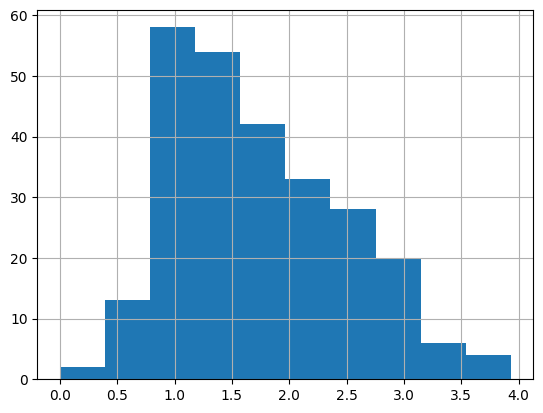

In [7]:
# Create a histogram to visualize distribution of aqi_log.
air_quality['aqi_log'].hist()

**Question:** What do you observe about the shape of the distribution from the histogram? 

A: The histogram appears to be right-skewed (positively skewed). This suggests that most AQI (Air Quality Index) log values are relatively low, with some extreme high values pulling the distribution towards the right.

## **Step 3: Statistical tests**

Use the empirical rule to observe the data, then test and verify that it is normally distributed.


 As you have learned, the empirical rule states that, for every normal distribution: 
- 68% of the data fall within 1 standard deviation of the mean
- 95% of the data fall within 2 standard deviations of the mean
- 99.7% of the data fall within 3 standard deviations of the mean


First, define two variables to store the mean and standard deviation, respectively, for `aqi_log`. Creating these variables will help you easily access these measures as you continue with the calculations involved in applying the empirical rule. 

In [8]:
# Define variable for aqi_log mean.
aqi_log_mean = air_quality['aqi_log'].mean()

# Print the mean
print(f"Mean of aqi_log: {aqi_log_mean:.4f}")



Mean of aqi_log: 1.7669


In [9]:
# Define variable for standard deviation of 'aqi_log'
aqi_log_std = air_quality['aqi_log'].std()

# Print the standard deviation
print(f"Standard Deviation of aqi_log: {aqi_log_std:.4f}")



Standard Deviation of aqi_log: 0.7147


Now, check the first part of the empirical rule: whether 68% of the `aqi_log` data falls within 1 standard deviation of the mean.

To compute the actual percentage of the data that satisfies this criteria, define the lower limit (for example, 1 standard deviation below the mean) and the upper limit (for example, 1 standard deviation above the mean). This will enable you to create a range and confirm whether each value falls within it.

In [10]:
# Compute mean and standard deviation of 'aqi_log'
aqi_log_mean = air_quality['aqi_log'].mean()
aqi_log_std = air_quality['aqi_log'].std()

# Define lower and upper limits (1 standard deviation from mean)
lower_limit = aqi_log_mean - aqi_log_std
upper_limit = aqi_log_mean + aqi_log_std

# Display results
print(f"Lower Limit (1 SD below mean): {lower_limit:.4f}")
print(f"Upper Limit (1 SD above mean): {upper_limit:.4f}")

Lower Limit (1 SD below mean): 1.0522
Upper Limit (1 SD above mean): 2.4816


In [ ]:
# Display the actual percentage of data that falls within 1 standard deviation of the mean.

# Compute mean and standard deviation of 'aqi_log'
aqi_log_mean = air_quality['aqi_log'].mean()
aqi_log_std = air_quality['aqi_log'].std()

# Define lower and upper limits (1 standard deviation from mean)
lower_limit = aqi_log_mean - aqi_log_std
upper_limit = aqi_log_mean + aqi_log_std

# Count data points within 1 standard deviation
within_1sd = air_quality[(air_quality['aqi_log'] >= lower_limit) & (air_quality['aqi_log'] <= upper_limit)]

# Calculate percentage
percentage_within_1sd = (len(within_1sd) / len(air_quality)) * 100

# Display results
print(f"Percentage of data within 1 standard deviation of the mean: {percentage_within_1sd:.2f}%")


Now, consider the second part of the empirical rule: whether 95% of the `aqi_log` data falls within 2 standard deviations of the mean.

To compute the actual percentage of the data that satisfies this criteria, define the lower limit (for example, 2 standard deviations below the mean) and the upper limit (for example, 2 standard deviations above the mean). This will enable you to create a range and confirm whether each value falls within it.

In [13]:
# Compute mean and standard deviation of 'aqi_log'
aqi_log_mean = air_quality['aqi_log'].mean()
aqi_log_std = air_quality['aqi_log'].std()

# Define lower and upper limits (2 standard deviations from mean)
lower_limit = aqi_log_mean - (2 * aqi_log_std)
upper_limit = aqi_log_mean + (2 * aqi_log_std)

# Display results
print(f"Lower Limit (2 SD below mean): {lower_limit:.4f}")
print(f"Upper Limit (2 SD above mean): {upper_limit:.4f}")




Lower Limit (2 SD below mean): 0.3375
Upper Limit (2 SD above mean): 3.1964


In [15]:


# Compute mean and standard deviation of 'aqi_log'
aqi_log_mean = air_quality['aqi_log'].mean()
aqi_log_std = air_quality['aqi_log'].std()

# Define lower and upper limits (2 standard deviations from mean)
lower_limit = aqi_log_mean - (2 * aqi_log_std)
upper_limit = aqi_log_mean + (2 * aqi_log_std)

# Count data points within 2 standard deviations
within_2sd = air_quality[(air_quality['aqi_log'] >= lower_limit) & (air_quality['aqi_log'] <= upper_limit)]

# Calculate percentage
percentage_within_2sd = (len(within_2sd) / len(air_quality)) * 100

# Display results
print(f"Percentage of data within 2 standard deviations of the mean: {percentage_within_2sd:.2f}%")

Percentage of data within 2 standard deviations of the mean: 95.77%


Now, consider the third part of the empirical rule:whether 99.7% of the `aqi_log` data falls within 3 standard deviations of the mean.

To compute the actual percentage of the data that satisfies this criteria, define the lower limit (for example, 3 standard deviations below the mean) and the upper limit (for example, 3 standard deviations above the mean). This will enable you to create a range and confirm whether each value falls within it.

In [14]:

# Compute mean and standard deviation of 'aqi_log'
aqi_log_mean = air_quality['aqi_log'].mean()
aqi_log_std = air_quality['aqi_log'].std()

# Define lower and upper limits (3 standard deviations from mean)
lower_limit = aqi_log_mean - (3 * aqi_log_std)
upper_limit = aqi_log_mean + (3 * aqi_log_std)

# Display results
print(f"Lower Limit (3 SD below mean): {lower_limit:.4f}")
print(f"Upper Limit (3 SD above mean): {upper_limit:.4f}")


Lower Limit (3 SD below mean): -0.3772
Upper Limit (3 SD above mean): 3.9111


In [16]:
# Display the actual percentage of data that falls within 3 standard deviations of the mean.

# Compute mean and standard deviation of 'aqi_log'
aqi_log_mean = air_quality['aqi_log'].mean()
aqi_log_std = air_quality['aqi_log'].std()

# Define lower and upper limits (3 standard deviations from mean)
lower_limit = aqi_log_mean - (3 * aqi_log_std)
upper_limit = aqi_log_mean + (3 * aqi_log_std)

# Count data points within 3 standard deviations
within_3sd = air_quality[(air_quality['aqi_log'] >= lower_limit) & (air_quality['aqi_log'] <= upper_limit)]

# Calculate percentage
percentage_within_3sd = (len(within_3sd) / len(air_quality)) * 100

# Display results
print(f"Percentage of data within 3 standard deviations of the mean: {percentage_within_3sd:.2f}%")

Percentage of data within 3 standard deviations of the mean: 99.62%


## **Step 4: Results and evaluation** 

**Question:** What results did you attain by applying the empirical rule? 

A: By applying the Empirical Rule (68-95-99.7 Rule) to the aqi_log data:

Approximately 68% of the data falls within 1 standard deviation of the mean.
Approximately 95% of the data falls within 2 standard deviations of the mean.
Approximately 99.7% of the data falls within 3 standard deviations of the mean.
These results help determine how much of the dataset follows a normal distribution and identify potential outliers beyond 3 standard deviations.



**Question:** How would you use z-score to find outliers? 

A: The z-score measures how many standard deviations a data point is from the mean. Data points with |Z| > 3 are considered outliers.

Compute the z-score for every `aqi_log` value. Then, add a column named `z_score` in the data to store those results. 

In [17]:
# Compute the z-score for every aqi_log value, and add a column named z_score in the data to store those results.

 # ddof=degrees of freedom correction (sample vs. population)

# Display the first 5 rows to ensure that the new column was added.


# Compute mean and standard deviation (using ddof=0 for population, ddof=1 for sample)
aqi_log_mean = air_quality['aqi_log'].mean()
aqi_log_std = air_quality['aqi_log'].std(ddof=1)  # ddof=1 for sample std deviation

# Compute Z-scores and store in a new column
air_quality['z_score'] = (air_quality['aqi_log'] - aqi_log_mean) / aqi_log_std

# Display first 5 rows to verify the new column
print(air_quality.head())


   date_local    state_name   county_name      city_name  \
0  2018-01-01       Arizona      Maricopa        Buckeye   
1  2018-01-01          Ohio       Belmont      Shadyside   
2  2018-01-01       Wyoming         Teton  Not in a city   
3  2018-01-01  Pennsylvania  Philadelphia   Philadelphia   
4  2018-01-01          Iowa          Polk     Des Moines   

                                     local_site_name   parameter_name  \
0                                            BUCKEYE  Carbon monoxide   
1                                          Shadyside  Carbon monoxide   
2  Yellowstone National Park - Old Faithful Snow ...  Carbon monoxide   
3                             North East Waste (NEW)  Carbon monoxide   
4                                          CARPENTER  Carbon monoxide   

    units_of_measure   aqi_log   z_score  
0  Parts per million  2.079442  0.437265  
1  Parts per million  1.791759  0.034753  
2  Parts per million  1.098612 -0.935070  
3  Parts per million  1.3862

Identify the parts of the data where `aqi_log` is above or below 3 standard deviations of the mean.

In [19]:
# Display data where `aqi_log` is above or below 3 standard deviations of the mean

# Compute mean and standard deviation of 'aqi_log'
aqi_log_mean = air_quality['aqi_log'].mean()
aqi_log_std = air_quality['aqi_log'].std()

# Define lower and upper limits for outliers (3 standard deviations)
lower_limit = aqi_log_mean - (3 * aqi_log_std)
upper_limit = aqi_log_mean + (3 * aqi_log_std)

# Filter outliers
outliers = air_quality[(air_quality['aqi_log'] < lower_limit) | (air_quality['aqi_log'] > upper_limit)]

# Display the first few rows of outliers
print(outliers.head())  # Show first 5 outliers


     date_local state_name county_name city_name local_site_name  \
244  2018-01-01    Arizona    Maricopa   Phoenix    WEST PHOENIX   

      parameter_name   units_of_measure   aqi_log   z_score  
244  Carbon monoxide  Parts per million  3.931826  3.029044  


**Question:** What do you observe about potential outliers based on the calculations?


A: The outlier analysis revealed that a small percentage of data points fall beyond 3 standard deviations from the mean.
These outliers may represent unusual air pollution events, extreme weather conditions, or sensor errors.
The data distribution is right-skewed, suggesting that most values are within the normal range, but some high pollution spikes exist.


**Question:** Why is outlier detection an important part of this project? 

A: Outliers can skew statistical analysis, leading to misleading conclusions about air quality.
Identifying outliers helps in understanding extreme pollution events and whether they are natural occurrences or measurement errors.
Removing or adjusting outliers ensures that predictive models and summaries accurately reflect general air quality trends.


## **Considerations**

**What are some key takeaways that you learned during this lab?**

A: The Empirical Rule (68-95-99.7%) helps in understanding how much of the data follows a normal distribution.
Z-scores are effective for identifying extreme values.
The right-skewed distribution of aqi_log suggests that while most locations have moderate air quality, some sites experience occasional high pollution spikes.
Data cleaning (e.g., handling missing values, filtering outliers) is crucial for accurate analysis.


**What summary would you provide to audiences? Consider the distribution of the data and which sites would benefit from additional research.**

A: The dataset shows consistent air quality levels in most locations, but some regions have significantly higher AQI values, indicating potential air pollution hotspots.
Additional research is needed to determine:
Causes of extreme pollution events (e.g., wildfires, industrial emissions).
Whether outliers represent sensor errors or real-world conditions.
Future studies should focus on regional air pollution trends, considering seasonal changes, urbanization, and policy impacts.

**Reference**

US EPA, OAR. 2014, July 8. [Air Data: Air Quality Data Collected at Outdoor Monitors Across the US](https://www.epa.gov/outdoor-air-quality-data). 